In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
PROJECT_ROOT = Path.cwd().parent
REPORTS_DIR = PROJECT_ROOT / "github-files"/ "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

In [8]:
from pathlib import Path

print("PROJECT_ROOT:", PROJECT_ROOT)
print("REPORTS_DIR:", REPORTS_DIR)
print("Exists:", REPORTS_DIR.exists())
print("Files:", list(REPORTS_DIR.glob("*")))


PROJECT_ROOT: c:\Users\jnaid\Music\CECS_499
REPORTS_DIR: c:\Users\jnaid\Music\CECS_499\github-files\reports
Exists: True
Files: [WindowsPath('c:/Users/jnaid/Music/CECS_499/github-files/reports/exclusion_summary.txt'), WindowsPath('c:/Users/jnaid/Music/CECS_499/github-files/reports/figures'), WindowsPath('c:/Users/jnaid/Music/CECS_499/github-files/reports/run_summary.csv'), WindowsPath('c:/Users/jnaid/Music/CECS_499/github-files/reports/subject_summary.csv')]


exploratory visualizations


In [9]:
run_df = pd.read_csv(REPORTS_DIR / "run_summary.csv")
subject_df = pd.read_csv(REPORTS_DIR / "subject_summary.csv")
run_df, subject_df

(    source_folder subject_id run_id                 file_name  \
 0              S1       S102  run03   S102_run03_updated.nirs   
 1              S1       S103  run02   S103_run02_updated.nirs   
 2              S1       S104  run03   S104_run03_updated.nirs   
 3              S1       S105  run02   S105_run02_updated.nirs   
 4              S1       S106  run02   S106_run02_updated.nirs   
 ..            ...        ...    ...                       ...   
 120            S3      L3124  run01  L3124_run01_updated.nirs   
 121            S3      L3125  run01  L3125_run01_updated.nirs   
 122            S3      L3126  run01  L3126_run01_updated.nirs   
 123            S3      L3127  run01  L3127_run01_updated.nirs   
 124            S3      L3130  run01  L3130_run01_updated.nirs   
 
                                    processed_file_path  s_rows  s_cols  \
 0    C:\Users\jnaid\Music\CECS_499\github-files\pri...   16025       2   
 1    C:\Users\jnaid\Music\CECS_499\github-files\pri... 

In [35]:
l= []
for i in range(len(subject_df)):
    #print(f"{df['subject_label']}")
    l.append(df['subject_label'])


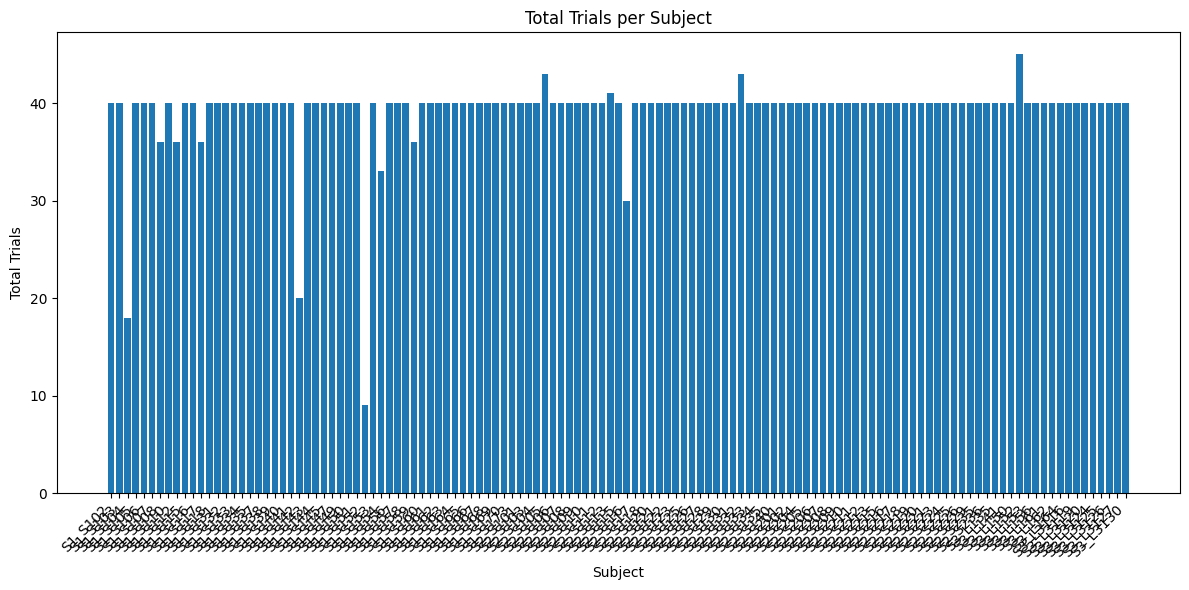

In [ ]:
df = subject_df.copy()
df["subject_label"] = df["source_folder"] + "_" + df["subject_id"].astype(str)
df = df.sort_values(["source_folder", "subject_id"])

plt.figure(figsize=(12, 6))
plt.bar(df["subject_label"], df["total_trials"])
plt.title("Total Trials per Subject")
plt.xlabel("Subject")
plt.ylabel("Total Trials")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

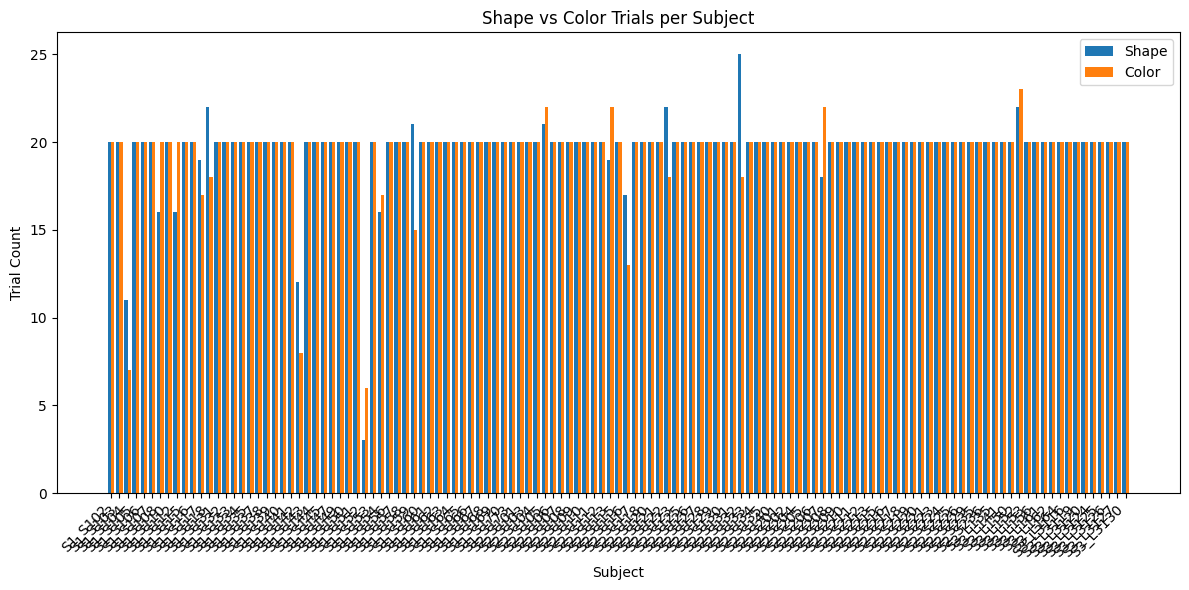

In [ ]:
df = subject_df.copy()
df["subject_label"] = df["source_folder"] + "_" + df["subject_id"].astype(str)
df = df.sort_values(["source_folder", "subject_id"])

x = range(len(df))
width = 0.4

plt.figure(figsize=(12, 6))
plt.bar([i - width / 2 for i in x], df["total_shape_trials"], width=width, label="Shape")
plt.bar([i + width / 2 for i in x], df["total_color_trials"], width=width, label="Color")
plt.title("Shape vs Color Trials per Subject")
plt.xlabel("Subject")
plt.ylabel("Trial Count")
plt.xticks(list(x), df["subject_label"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

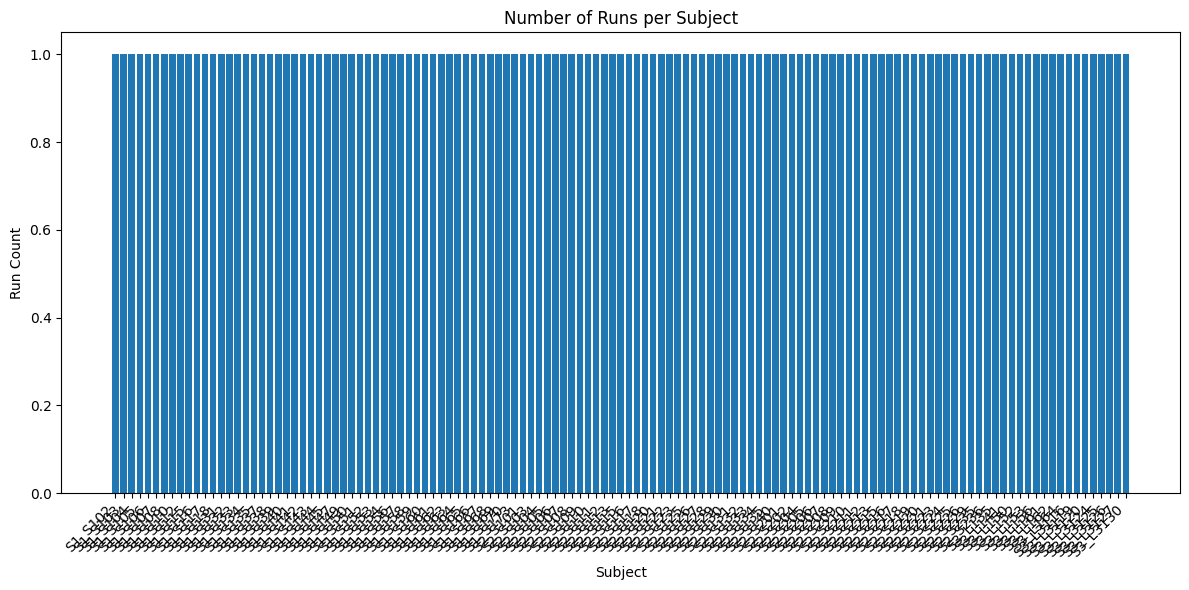

In [ ]:
df = subject_df.copy()
df["subject_label"] = df["source_folder"] + "_" + df["subject_id"].astype(str)
df = df.sort_values(["source_folder", "subject_id"])

plt.figure(figsize=(12, 6))
plt.bar(df["subject_label"], df["num_runs"])
plt.title("Number of Runs per Subject")
plt.xlabel("Subject")
plt.ylabel("Run Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



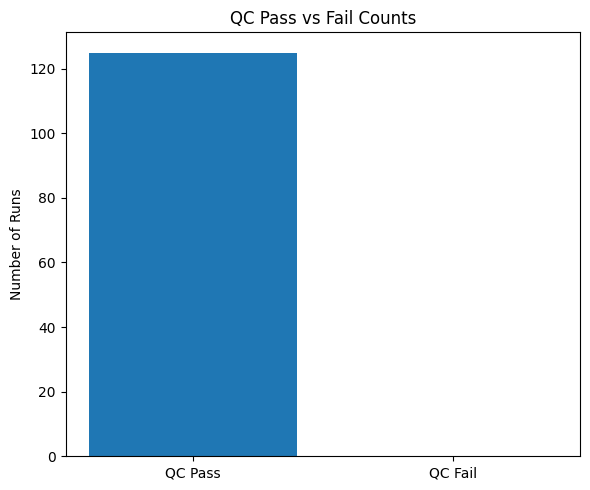

In [ ]:
pass_count = int(run_df["qc_pass"].sum())
fail_count = int((~run_df["qc_pass"]).sum())

plt.figure(figsize=(6, 5))
plt.bar(["QC Pass", "QC Fail"], [pass_count, fail_count])
plt.title("QC Pass vs Fail Counts")
plt.ylabel("Number of Runs")
plt.tight_layout()

plt.show()
